In [82]:
from datetime import datetime
import numpy as np
import pandas as pd
import re
pd.set_option("display.max_rows", 310)
pd.set_option('display.max_columns', 30)
import matplotlib.pyplot as plt
import urllib.request
from bs4 import BeautifulSoup
import sqlite3
from contextlib import closing # 
sqlite3.register_adapter(np.int64, lambda val: int(val)) # dataframe <-> sqlite3
from selenium import webdriver
from selenium.webdriver.common.by import By
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
from selenium.common.exceptions import TimeoutException
import warnings
warnings.filterwarnings('ignore')
# import importlib
# importlib.reload(mr)
import myrace as mr
from mycolor import * 
print("code loading ", datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

code loading  2019/10/22 00:42:56


In [354]:
""" レース結果の登録 """
rc = mr.grc("東京mon") + '11'
url = "http://race.netkeiba.com/?pid=race&id=c" + rc + "&mode=result"
driver = webdriver.PhantomJS()
driver.get(url)
df = pd.io.html.read_html(driver.page_source)
result_df = df[0].copy()
result_df.fillna('', inplace=True) # nan削除

In [355]:
lst = [(rc,) + tuple(result_df.iloc[i].values) for i in range(len(result_df))]
with closing(sqlite3.connect("racing.sqlite3")) as conn:
    cur = conn.cursor()
    sql = "INSERT INTO Result(racecode,\
    rank, stall, number, horse, sexage, impost, jockey, time, margin,\
    popularity, odds, last3halon, passing, trainer, weight)\
    Values(?,?,?,?,?,?,?,?,?,?,?,?,?,?,?,?)"
    try:
        cur.executemany(sql, lst)
    except sqlite3.Error as e:
        print('sqlite3.Error occurred:', e.args[0])
    conn.commit()
    conn.close()
print("code loading ", datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

code loading  2019/10/22 17:17:45


In [356]:
""" 払い戻しの登録 """
def spl(str):
    if('円' in str):
        s = str.replace('円','円,', 2)
        return s.split(',')
    if('人気' in str):
        s = str.replace('人気','人気,', 2)
        return s.split(',')

def rebuild_payoff(concat_df): # 複勝・ワイドなどの表記を再構築したdataframeを返す
    win = concat_df.iloc[0][0:4] # 単勝
    p = concat_df.iloc[1][1:4]
    place1 = pd.Series({0:'複勝1', 1: p[1][0:2], 2: spl(p[2])[0], 3: spl(p[3])[0]})
    place2 = pd.Series({0:'複勝2', 1: p[1][2:4], 2: spl(p[2])[1], 3: spl(p[3])[1]})
    place3 = pd.Series({0:'複勝3', 1: p[1][4:6], 2: spl(p[2])[2], 3: spl(p[3])[2]})
    bracket = concat_df.iloc[2][0:4] # 枠連
    quinella = concat_df.iloc[3][0:4] # 馬連
    w = concat_df.iloc[4][1:4]
    wide1 = pd.Series({0:'ワイド1', 1: w[1][0:7], 2: spl(w[2])[0], 3: spl(w[3])[0]}) # ワイド1
    wide2 = pd.Series({0:'ワイド2', 1: w[1][7:14], 2: spl(w[2])[1], 3: spl(w[3])[1]}) # ワイド2
    wide3 = pd.Series({0:'ワイド3', 1: w[1][14:21], 2: spl(w[2])[2], 3: spl(w[3])[2]}) # ワイド3
    exacta = concat_df.iloc[5][0:4] # 馬単
    trio = concat_df.iloc[6][0:4] # 三連複
    trifecta = concat_df.iloc[7][0:4] # 三連単
    payoff_df = pd.DataFrame([win, place1, place2, place3, bracket, quinella,\
                              wide1, wide2, wide3, exacta, trio, trifecta])
    payoff_df.index = list(range(12))
    payoff_df.columns = columns=['券種', '入賞', '配当', '人気']
    return payoff_df

concat_df = pd.concat([df[1], df[2]])
payoff_df = rebuild_payoff(concat_df)

In [357]:
lst = [(rc,) + tuple(payoff_df.iloc[i].values) for i in range(len(payoff_df))]
with closing(sqlite3.connect("racing.sqlite3")) as conn:
    cur = conn.cursor()
    sql = "INSERT INTO Payoff(racecode,\
    tiket, winnig, payoff, popularity) Values(?,?,?,?,?)"
    try:
        cur.executemany(sql, lst)
    except sqlite3.Error as e:
        print('sqlite3.Error occurred:', e.args[0])
    conn.commit()
    conn.close()
print("code loading ", datetime.now().strftime("%Y/%m/%d %H:%M:%S"))

code loading  2019/10/22 17:17:56


In [4]:
 def get_odds(cc):
    odds_lst = []
    for i in range(1, 13):
        url = "http://race.netkeiba.com/?pid=odds&id=c2019" + cc + str(i).rjust(2,"0") + "&mode=top"
        driver = webdriver.PhantomJS()
        driver.get(url)
        df = pd.io.html.read_html(driver.page_source)
        odds_df = df[3]
        bar = [round((0.8 / odds)*100, 2) for odds in df[3]['単勝オッズ']]
        x = df[3]['馬番'].index
        print(f"{i}R Ok!")
        odds_lst.append((odds_df, bar, x))
    return odds_lst

In [26]:
cc = mr.grc("東京mon")
odds_lst = get_odds(cc)
print("ok")

1R Ok!
2R Ok!
3R Ok!
4R Ok!
5R Ok!
6R Ok!
7R Ok!
8R Ok!
9R Ok!
10R Ok!
11R Ok!
12R Ok!
ok


1R


,単勝人気,枠番,馬番,馬名,単勝オッズ,複勝オッズ
0,1,6,9,ユークレース,3.2,1.3-1.6
1,2,3,3,セイレーンズベルン,5.1,1.5-2.1
2,3,8,12,アスティパレア,5.2,1.5-2.2
3,4,4,4,ラブリーエンジェル,7.8,1.6-2.3
4,5,5,7,エオスモン,8.5,2.2-3.2
5,6,8,13,クーレクー,9.0,2.7-4.1
6,7,6,8,シェーブルドール,18.1,3.8-5.9
7,8,1,1,ルミナスナイト,24.2,4.8-7.5
8,9,7,11,アラビアンルビー,80.1,14.7-23.8
9,10,5,6,ラララ,80.4,14.9-24.0


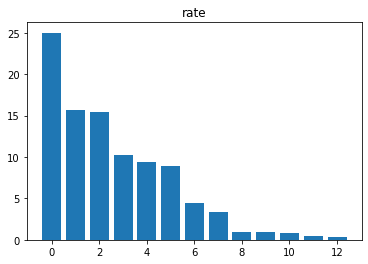

In [27]:
i = 1
print(f"{i}R")
tpl = odds_lst[i-1]
display(tpl[0])
bar = tpl[1]
x = tpl[2]
plt.title('rate')
plt.bar(x, bar)
plt.show()

In [51]:
""" 単勝合成オッズの配分 """
r = 6
lst = odds_lst[r-1][0]['単勝オッズ'][0:4]
odds = [os for os in lst]
comp = [round(1/os,3) for os in lst]
bets = [round(cp*2000) for cp in comp]
refund = [round(os*bt) for os, bt in zip(odds, bets)]
print(odds)
print(comp)
print(bets)
print(np.sum(bets))
print(refund)

[4.1, 4.1, 5.8, 9.6]
[0.244, 0.244, 0.172, 0.104]
[488, 488, 344, 208]
1528
[2001, 2001, 1995, 1997]
